In [65]:
from colossus.cosmology import cosmology
from colossus.halo import profile_nfw
from colossus.halo import concentration
cosmology.setCosmology('planck18')
#credit original paper / code

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import truncnorm

from slsim.Deflectors.MassLightConnection.galaxy_population import gals_init, stellarmass_halomass

from slsim.Sources.SourcePopulation.galaxies import Galaxies
import slsim.Pipelines as pipelines
import slsim.Deflectors as deflectors

from slsim.Lenses.lens_pop import LensPop
from slsim.Lenses.lens import Lens

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy.units import Quantity
from astropy.cosmology import FlatLambdaCDM
from astropy.table import Table

from slsim.Pipelines import roman_speclite
import speclite

import warnings
import time
import random

from slsim.Deflectors.deflector_util import deflector_from_table

from slsim.ImageSimulation.image_simulation import simulate_image
from astropy.visualization import make_lupton_rgb
from slsim.Util.euclid_rgb_util import (
    euclid_rgb_from_image_list,
    euclid_nisp_num_pix_from_vis,
)

from astropy.table import vstack

from slsim.Deflectors.deflector_group import DeflectorGroup

from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Util.util import make_grid

In [66]:
def accreted_subhalo_density_pdf(p_nfw, m_acc):
    #m_acc: subhalo accretion mass [solar masses]
    #returns: dN / dlnm
    
    R200, M200 = p_nfw.RMDelta(1.0, "200c") #kpc/h, M_solar/h

    m0 = 10 ** 10
    m = m_acc / m0
    M = M200 / m0
    
    A = 0.1*M**-0.02  # infall mass function amplitude
    alpha = 0.95  # infall mass function slope
    mustar = 0.5*M**-0.03  # stripping function amplitude
    beta = 1.7*M**-0.04  # stripping function slope
    sigma = 1.1 # log scatter of m / m_acc
    fs = 0.55  # fraction of survived subhaloes
    B = 0.6

    return (
        A *
        M *
        m ** -alpha
    )

#When selecting by accretion mass, final position traces host halo density
def unevolved_spatial_distribution_pdf(p_nfw, r):
    #r: distance to halo center [kpc]
    #returns: dN / d3r

    R200, M200 = p_nfw.RMDelta(1.0, "200c") #kpc/h, M_solar/h
    return p_nfw.density(r) / M200

def evolved_subhalo_mass_fraction_of_accretion(p_nfw, r):
    #r: distance to halo center [kpc]
    #return: m_evolved / m_acc

    R200, M200 = p_nfw.RMDelta(1.0, "200c") #kpc/h, M_solar/h

    m0 = 10 ** 10
    M = M200 / m0
    
    A = 0.1*M**-0.02  # infall mass function amplitude
    alpha = 0.95  # infall mass function slope
    mustar = 0.5*M**-0.03  # stripping function amplitude
    beta = 1.7*M**-0.04  # stripping function slope
    sigma = 1.1 # log scatter of m / m_acc
    fs = 0.55  # fraction of survived subhaloes
    B = 0.6

    mubar = mustar * (r / R200) ** beta #average evolved mass fraction
    mu = np.random.lognormal(mean = np.log(mubar), sigma = sigma) #with scatter

    return np.where(np.random.rand(*r.shape) < fs, mu, 0) #0 mass when stripped

In [67]:
def generate_subhalos(p_nfw, m_acc_min, m_acc_max):
    R200, M200 = p_nfw.RMDelta(1.0, "200c")

    m_acc = np.logspace(np.log10(m_acc_min), np.log10(m_acc_max), num=1000, base=10)
    r = R200 * np.logspace(-3, 0, num=1000, base=10) #TODO artificially limiting distance to R200 good call?

    d3r = 4/3 * np.pi * (r[1:] ** 3 - r[:-1] ** 3)
    #probability that the accreeted subhalo ended up at each radius (traces halo density profile)
    spacial_distribution_multiplier = unevolved_spatial_distribution_pdf(p_nfw, r[:-1]) * d3r

    dlnm = np.log(m_acc[1]) - np.log(m_acc[0])

    out_mass_acc = np.array([])
    out_mass_evolved = np.array([])
    out_radius = np.array([])

    for _m in m_acc:
        #expected number of accreted subhalos of this mass
        accreted_subhalo_expected = accreted_subhalo_density_pdf(p_nfw, _m) * dlnm

        probability_present = spacial_distribution_multiplier * accreted_subhalo_expected

        #faster than poisson
        present_r_indices = np.where(np.random.rand(*probability_present.shape) < probability_present)[0]

        out_mass_acc = np.append(out_mass_acc, [_m] * len(present_r_indices))
        out_mass_evolved = np.append(out_mass_evolved, _m * evolved_subhalo_mass_fraction_of_accretion(p_nfw, r[present_r_indices]))
        out_radius = np.append(out_radius, r[present_r_indices])

    return out_mass_acc, out_mass_evolved, out_radius

In [68]:
def populate_galaxies(M, z, min_satellite_subhalo_mass):
    c = concentration.concentration(M, "200c", z, model="diemer19")
    c = np.random.lognormal(mean = np.log(c), sigma = 0.33) #concentration distribution 0.16 dex
    
    p_nfw = profile_nfw.NFWProfile(M = M, c = c, z = z, mdef = "200c")

    paramc, params = gals_init()

    galaxies = []

    #satellite galaxy
    stellarmass = stellarmass_halomass(M, z, paramc)
    stellarmass = np.random.lognormal(mean = np.log(stellarmass), sigma = 0.2)
    galaxies.append((M, stellarmass, (0, 0)))

    #subhalos
    for subhalo_m_acc, subhalo_m_evolved, subhalo_r in zip(*generate_subhalos(p_nfw, min_satellite_subhalo_mass, M)):
        #cast 3d radius to 2d
        pos = np.random.normal(size=(3))
        pos /= np.linalg.norm(pos)

        stellarmass = stellarmass_halomass(subhalo_m_acc, z, params)
        stellarmass = np.random.lognormal(mean = np.log(stellarmass), sigma = 0.2)
        
        pos_2d = pos[:2] * subhalo_r
        galaxies.append((subhalo_m_evolved, stellarmass, tuple(pos_2d)))
    
    return galaxies

In [69]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

sky_area = Quantity(value=0.5, unit="deg2")

# Magnitude limits for deflector and source galaxies
kwargs_deflector_cut = {"band": "g", "band_max": 26, "z_min": 0.2, "z_max": 1.0}
kwargs_source_cut = {"band": "g", "band_max": 26, "z_min": 0.21, "z_max": 5.0}

galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    sky_area=sky_area,
    filters=None,
)

galaxy_list = vstack([galaxy_simulation_pipeline.red_galaxies, galaxy_simulation_pipeline.blue_galaxies])
source_galaxies = Galaxies(
    # Use both red and blue galaxies as source / field galaxies
    galaxy_list=galaxy_list,
    kwargs_cut=kwargs_source_cut,
    cosmo=cosmo,
    sky_area=sky_area,
    catalog_type="skypy",
)

In [ ]:
def create_deflector(M, z, galaxy_list, min_satellite_subhalo_mass = 10 ** 11.5):
    galaxies = populate_galaxies(M, z, min_satellite_subhalo_mass)
    
    light_dicts = []
    mass_dicts = []
    center_x_list = []
    center_y_list = []

    log_skypy_galaxy_masses = np.log10(galaxy_list["stellar_mass"]) #avoid recomputation
    for subhalo_mass, galaxy_mass, galaxy_r in galaxies:
        closest_real_galaxy_index = np.argmin(np.hypot(galaxy_list["z"] - z, log_skypy_galaxy_masses - np.log10(galaxy_mass)))

        #print(f"({np.log10(galaxy_mass):.4f}, {z:.4f}) -> ({np.log10(galaxy_list[closest_real_galaxy_index]['stellar_mass']):.4f}, {galaxy_list[closest_real_galaxy_index]['z']:.4f})")
        #print(f"z: {z}, galaxy stellar mass: {galaxy_mass}")
        #print(galaxy_list[closest_real_galaxy_index])

        light_dict = dict(galaxy_list[closest_real_galaxy_index])
        del light_dict["z"]
        light_dict["extended_source_type"] = "hernquist"

        #angle = np.random.rand() * 2 * np.pi
        #ellipticity = truncnorm.rvs((0 - 0.3) / .16, (.9 - .3) / .16, loc = .3, scale = .16) #truncated normal, mean .3 disp .16
        light_dict["e1"] = 0 #ellipticity * np.cos(angle)
        light_dict["e2"] = 0 #ellipticity * np.sin(angle)

        if subhalo_mass > 0:
            c = concentration.concentration(subhalo_mass, "200c", z, model="diemer19")
            c = np.random.lognormal(mean = np.log(c), sigma = 0.33) #concentration distribution 0.16 dex
            mass_dict = {"mass_type": "NFW_HERNQUIST", "halo_mass": subhalo_mass, "concentration": c, "e1": 0, "e2": 0}
        else:
            mass_dict = {"mass_type": "HERNQUIST"}

        angular_diameter_dist = cosmo.angular_diameter_distance(z).to("kpc").value
        center_x = galaxy_r[0] / angular_diameter_dist * 206265
        center_y = galaxy_r[1] / angular_diameter_dist * 206265
        
        if (-40 < center_x < 40) and (-40 < center_y < 40):
        #if (-80 < center_x < 80) and (-80 < center_y < 80):
            light_dicts.append(light_dict)
            mass_dicts.append(mass_dict)
            center_x_list.append(center_x)
            center_y_list.append(center_y)

    return {
        "kwargs_mass_list": mass_dicts,
        "kwargs_light_list": light_dicts,
        "center_x_deflector_list": center_x_list,
        "center_y_deflector_list": center_y_list
    }

In [101]:
class Deflectors:
    def __init__(self, M, z):
        self.sky_area = Quantity(0.05, "deg2")
        self.deflectors = []

        for i in range(20):
            deflector = create_deflector(M, z, galaxy_list)
            self.deflectors.append(DeflectorGroup(z, **deflector))

    def draw_deflector(self):
        #print("selected")
        return random.choice(self.deflectors)
    
    def deflector_number(self):
        return len(self.deflectors)
    

deflectors = Deflectors(10 ** 14.6, .6)

In [102]:
lenspop = LensPop(
    deflector_population=deflectors,
    source_population=source_galaxies,
    cosmo=cosmo,
    sky_area=sky_area,
)

# Render width in arcsecs
RENDER_WIDTH = 80

# Ensure we draw enough source galaxies to cover the entire rendered area
render_area = Quantity(np.pi / 2 * RENDER_WIDTH**2, "arcsec2")

# To pass into our select lens function
kwargs_lens_cut_plot = {
    "min_image_separation": 5.0,
    "max_image_separation": 100.0,
}

In [73]:
# Some plotting functions
def plot_objects(lens_system: Lens, ax):
    """
    Plot locations of source galaxies, deflector galaxies, and field galaxies in the source plane. Expects the deflector to be a cluster.

    :param lens_system: slsim.Lenses.Lens
    :param ax: matplotlib.axes.Axes
    """
    source_class = lens_system._source
    field_class = lens_system._field_galaxies
    deflector = lens_system.deflector

    ax.scatter(
        deflector._center_x_deflector_list,
        deflector._center_y_deflector_list,
        label="deflectors",
        alpha=0.5,
        s=10,
        color="red",
    )
    '''ax.scatter(
        [s.extended_source_position[0] for s in field_class],
        [s.extended_source_position[1] for s in field_class],
        label="field galaxies",
        alpha=0.5,
        s=10,
        color="yellow",
    )'''
    ax.scatter(
        [s.extended_source_position[0] for s in source_class],
        [s.extended_source_position[1] for s in source_class],
        label="sources",
        alpha=0.5,
        s=10,
        color="blue",
    )

    for i in range(len(deflector._center_x_deflector_list)):
        stellar_mass = lens_system.deflector._deflector_list[i].stellar_mass
        halo_mass = lens_system.deflector._deflector_list[i].mass_properties.get('halo_mass', 0)
        
        text = f"{np.log10(stellar_mass):.4f}; {np.log10(halo_mass) if halo_mass > 0 else 0:.4f}"
        ax.text(deflector._center_x_deflector_list[i], deflector._center_y_deflector_list[i], text, size='xx-small')

def plot_source_position_shift(lens_system: Lens, ax):
    """
    Plots the image position shift of sources.

    :param lens_system: slsim.Lenses.Lens
    :param ax: matplotlib.axes.Axes
    """
    source_class = lens_system._source
    image_positions = lens_system.extended_source_image_positions

    multi_imaged = 0
    for i in range(len(source_class)):
        if len(image_positions[i][0]) <= 1:
            color = "pink"
            lw = 0.25
        else:
            colors = "cmyrgb"
            color = colors[multi_imaged % len(colors)]
            multi_imaged += 1

            lw = 1.0

        for j in range(len(image_positions[i][0])):
            ax.plot(
                [source_class[i].extended_source_position[0], image_positions[i][0][j]],
                [source_class[i].extended_source_position[1], image_positions[i][1][j]],
                color=color,
                alpha=0.5,
                lw=lw,
            )

def plot_caustics(lens_system: Lens, ax):
    z_source = 10
    z_lens = lens_system.deflector.redshift

    lens_cosmo = LensCosmo(
        z_lens=z_lens,
        z_source=z_source,
        cosmo=cosmo,
    )

    lens_mass_model_list, model_params = lens_system.deflector.mass_model_lenstronomy(lens_cosmo)

    lens_model = LensModel(
        lens_model_list=lens_mass_model_list,
        cosmo=cosmo,
        z_lens=z_lens,
        z_source=z_source,
        multi_plane=False,
    )

    lens_model_ext = LensModelExtensions(lens_model)
    ra_crit_list, dec_crit_list, ra_caustic_list, dec_caustic_list = (
        lens_model_ext.critical_curve_caustics(
            model_params, compute_window=RENDER_WIDTH, grid_scale=.1 #RENDER_WIDTH*2
        )
    )

    for ra, dec in zip(ra_crit_list, dec_crit_list):
        ax.plot(ra, dec, color="r")

selected lens after 1 tries.


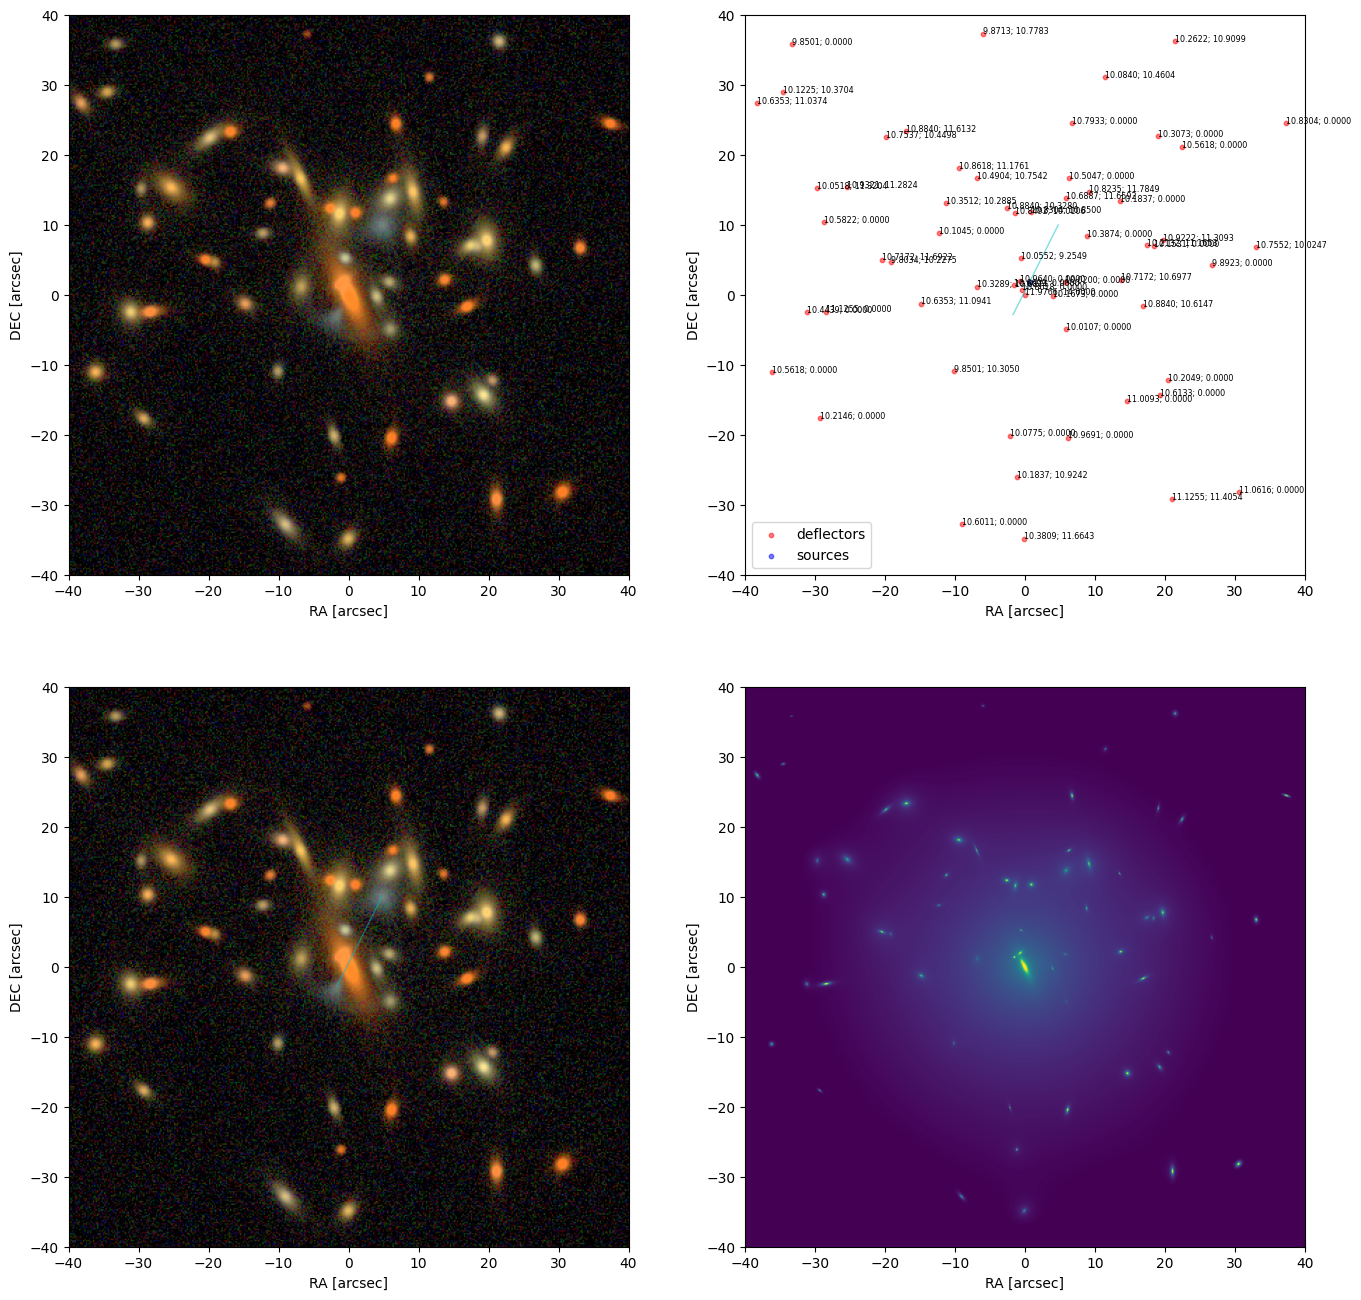

selected lens after 8 tries.


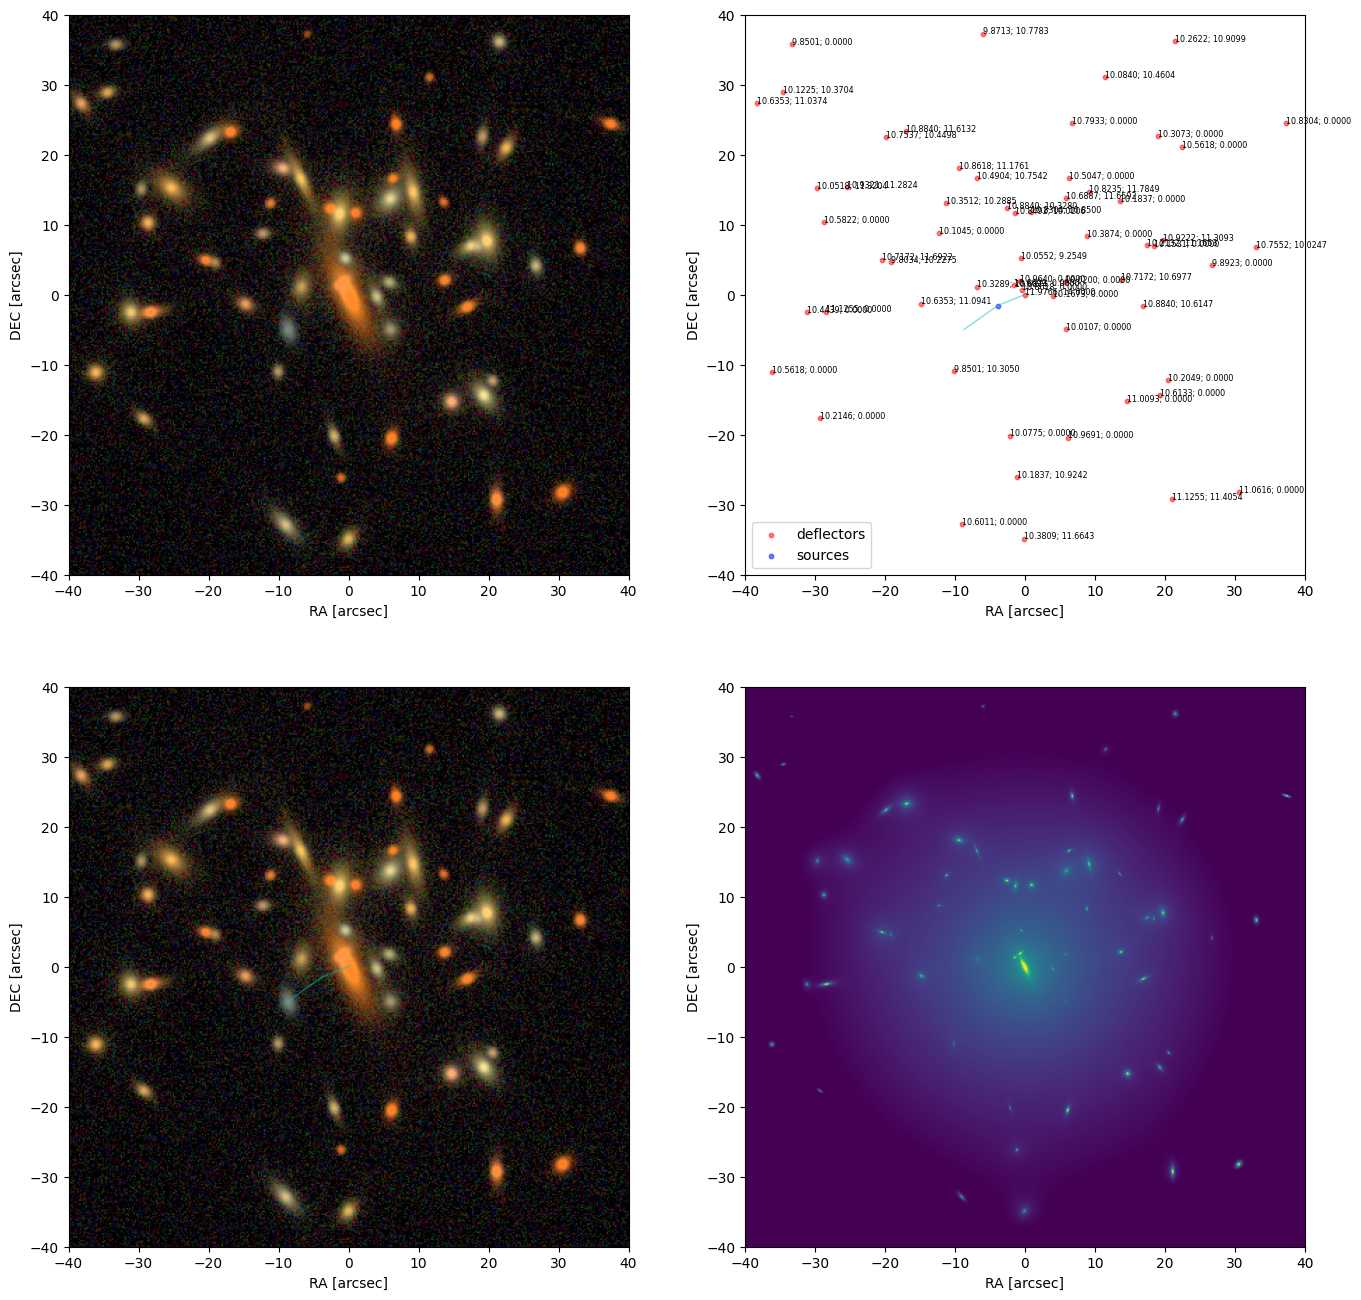

selected lens after 59 tries.


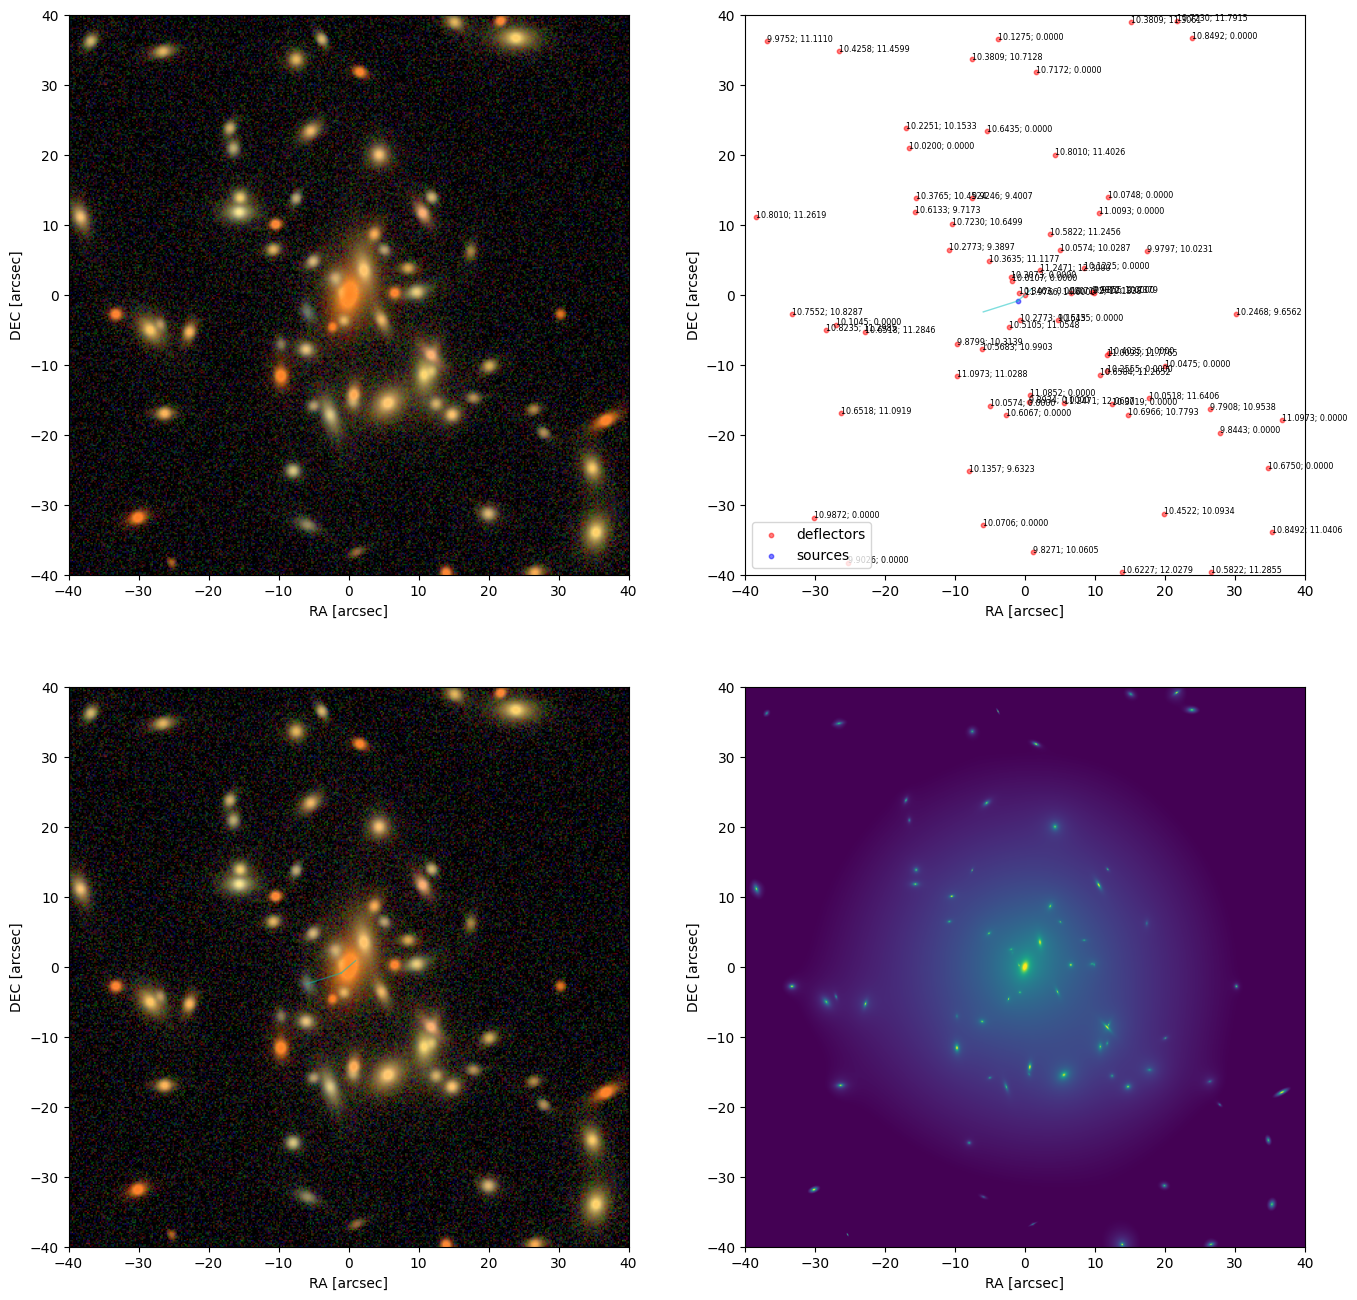

selected lens after 2 tries.


KeyboardInterrupt: 

In [103]:
for i in range(5):
    lens_system = lenspop.select_lens_at_random(verbose=True, **kwargs_lens_cut_plot)

    lsst_band_images = {}
    lsst_bands = ["i", "r", "g"]
    for band in lsst_bands:
        lsst_band_images[band] = simulate_image(
            lens_class=lens_system,
            band=band,
            observatory="LSST",
            num_pix=int(RENDER_WIDTH / 0.2),
            add_noise=True,
        )

    image_rgb_lsst = make_lupton_rgb(
        lsst_band_images["i"],
        lsst_band_images["r"],
        lsst_band_images["g"],
        minimum=0,
        stretch=0.5,
        Q=8,
    )

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 16))

    plt.setp(
        (ax1, ax2, ax3, ax4),
        xlim=(-RENDER_WIDTH / 2, RENDER_WIDTH / 2),
        ylim=(-RENDER_WIDTH / 2, RENDER_WIDTH / 2),
        xlabel="RA [arcsec]",
        ylabel="DEC [arcsec]",
        aspect="equal",
    )

    ax1.imshow(
        image_rgb_lsst,
        origin="lower",
        extent=[
            -RENDER_WIDTH / 2,
            RENDER_WIDTH / 2,
            -RENDER_WIDTH / 2,
            RENDER_WIDTH / 2,
        ],
    )

    plot_objects(lens_system, ax2)
    plot_source_position_shift(lens_system, ax2)
    ax2.legend()

    ax3.imshow(
        image_rgb_lsst,
        origin="lower",
        extent=[
            -RENDER_WIDTH / 2,
            RENDER_WIDTH / 2,
            -RENDER_WIDTH / 2,
            RENDER_WIDTH / 2,
        ],
    )
    plot_source_position_shift(lens_system, ax3)

    lensmodel, kwargs = lens_system.deflector_mass_model_lenstronomy()
    kappas = lensmodel.kappa(*make_grid(RENDER_WIDTH * 10, 1 / 10), kwargs).reshape(RENDER_WIDTH * 10, RENDER_WIDTH * 10)
    ax4.imshow(
        kappas,
        norm=LogNorm(vmin=np.percentile(kappas, 50), vmax=np.percentile(kappas, 99.99)),
        origin="lower",
        extent=[
            -RENDER_WIDTH / 2,
            RENDER_WIDTH / 2,
            -RENDER_WIDTH / 2,
            RENDER_WIDTH / 2,
        ],
    )
    #plot_caustics(lens_system, ax4)

    plt.savefig(f"../out/{time.time()}.png")
    plt.show()

In [242]:
members_catalog = Table.read("../data/redMaPPer/members_example.fits")

members_catalog

cluster_id,member_id,ra,dec,mag_g,mag_r,mag_i,mag_z
int16,int64,float64,float64,float32,float32,float32,float32
7,2929088686,70.210811,-47.799704,21.844,20.710,20.279,20.009
7,2929089143,70.247586,-47.796759,21.624,20.060,19.578,19.279
7,2929089918,70.186850,-47.786768,22.167,20.746,20.302,20.026
7,2929090333,70.181914,-47.782642,21.987,20.668,20.204,19.878
7,2929091665,70.241005,-47.767772,22.206,20.739,20.268,19.957
7,2929092478,70.226195,-47.759934,21.860,20.521,20.101,19.789
7,2929092787,70.232244,-47.757809,20.987,19.440,18.929,18.611
7,2929092925,70.185466,-47.757723,20.181,18.689,18.163,17.846
7,2929092959,70.187237,-47.756244,21.528,20.335,19.979,19.743


In [243]:
galaxy_simulation_pipeline.red_galaxies

z,M,coeff,ellipticity,physical_size,stellar_mass,angular_size,mag_g,mag_r,mag_i,mag_z,mag_y
,,,,kpc,,arcsec,,,,,
float64,float64,float64[5],float64,float64,float64,float64,float64,float64,float64,float64,float64
1.260810611119874,-20.888055658843907,0.01890655103381705 .. 0.0004099704453682411,0.28606586224442915,2.3983137282898164,147661836981.45227,0.2797869152137185,25.898240079787588,25.453612202443235,24.494117897606575,23.85963287086062,23.113617495046565
1.1041419545980484,-20.35028590037712,0.04381526322146196 .. 0.0005654133450103925,0.19633364630990155,1.872478547455594,89596146989.28076,0.22284994911771241,26.3016186414389,25.402176104036663,24.493568042938684,23.61601008830008,23.008613249950407
0.8906008601193709,-20.86349966401614,0.27359466846325226 .. 0.0026449600658607097,0.043253763464355444,1.648149911413266,104853730993.92557,0.2063458216276161,23.724682360765897,23.373002656349378,22.68757165404127,22.131136290168698,21.87222597019492
2.0727823893634603,-20.462008578453595,0.010863291625116726 .. 0.0005960912769124271,0.07919511884052258,1.0514589599750777,103925678651.20953,0.12310692024857094,29.06305179151442,28.675468444643894,28.281808277564178,27.270428307792894,26.331979064040812
0.6433399296558294,-20.10304610946591,0.1063940031596394 .. 0.00030474434608016753,0.11473321312225934,1.667105933640249,63338887658.98925,0.23470235634133363,24.17115101300449,23.12936349873567,22.149845719469766,21.784389054072108,21.505242617894005
2.2765047172091686,-22.211982306899568,0.004227364896791848 .. 0.00023264872177347753,0.045405400099302655,4.635871420446815,525851584988.11707,0.5506133682028622,26.999350463708595,26.85417108855632,26.599660340305853,26.161368048286896,25.198487329923815
0.4832872075060776,-20.496461987026436,0.08850117865555923 .. 1.9139857668880175e-05,0.03082094890292574,1.8701038687059572,108921071504.45499,0.3027324752358794,22.93175630315857,21.57060983720154,20.775118957348337,20.400732322668976,20.18061028789492
0.817226213792891,-21.005106956654707,0.10788439691169825 .. 0.0008957872920505444,0.17510822949168675,2.3364664275607927,174855763072.42493,0.30034996358405186,24.666881507329208,23.398376883039745,22.30256674028793,21.575990063264534,21.30686118550804


In [18]:
M = 10 ** 14.2

subhalo_masses = []
N = 1000

#M M* (pos)
for _ in range(N):
    for m, _, _ in populate_galaxies(M, .4, 10 ** 10):
        if m > 0:
            subhalo_masses.append(m)

subhalo_masses = np.array(subhalo_masses)

In [20]:
M = 10 ** 14.2

p_nfw = profile_nfw.NFWProfile(M=M, c=5.0, z=0.6, mdef="200c")

acc_mass = []
ev_mass = []
radius = []
N = 1000

#M M* (pos)
for _ in range(N):
    for m_acc, m_ev, r in zip(*generate_subhalos(p_nfw, 10 ** 10, M)):
        if m_ev > 0:
            acc_mass.append(m_acc)
            ev_mass.append(m_ev)
            radius.append(r)

mu = np.array(ev_mass) / np.array(acc_mass)
radius = np.array(radius)

(array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.]),
 array([-4.  , -3.92, -3.84, -3.76, -3.68, -3.6 , -3.52, -3.44, -3.36,
        -3.28, -3.2 , -3.12, -3.04, -2.96, -2.88, -2.8 , -2.72, -2.64,
        -2.56, -2.48, -2.4 , -2.32, -2.24, -2.16, -2.08, -2.  , -1.92,
        -1.84, -1.76, -1.68, -1.6 , -1.52, -1.44, -1.36, -1.28, -1.2 ,
        -1.12, -1.04, -0.96, -0.88, -0.8 , -0.72, -0.64, -0.56, -0.48,
        -0.4 , -0.32, -0.24, -0.16, -0.08,  0.  ]),
 <BarContainer object of 50 artists>)

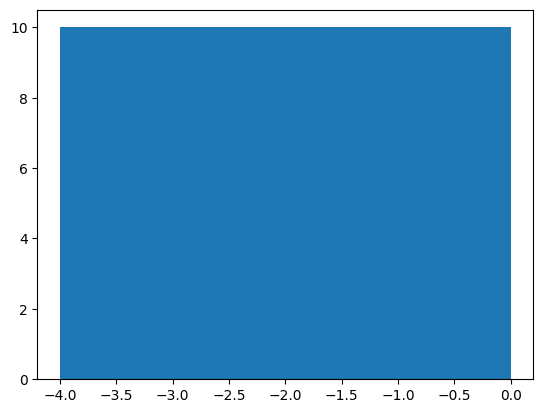

In [23]:
R200, M200 = p_nfw.RMDelta(0.6, "200c")
plt.hist(np.log10(mu[mu > 0]), bins=50)

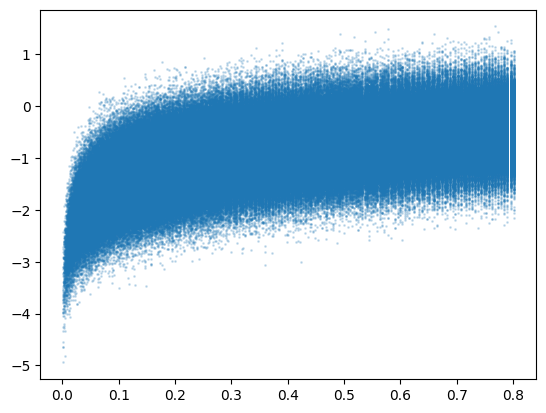

In [8]:
plt.scatter(
    radius/R200,
    np.log10(mu),
    s=1,
    alpha=0.2
)

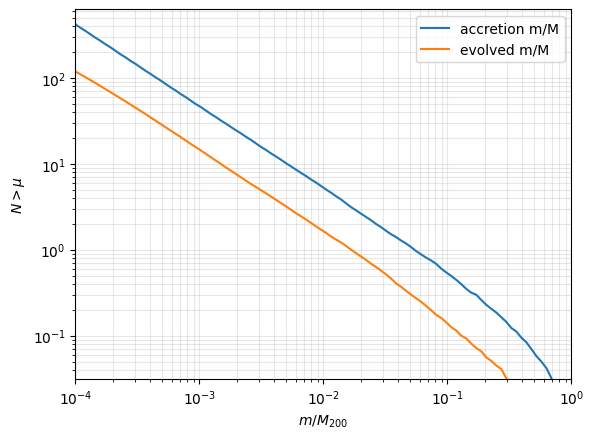

In [27]:
p_nfw = profile_nfw.NFWProfile(M=M, c=5.0, z=0.6, mdef="200c")

# Mass fractions m_acc / M200
mu = np.logspace(-4, 0, 500)

# Corresponding accretion masses
m_acc = mu * M

# dN / dlnm
dN_dlnm = accreted_subhalo_density_pdf(p_nfw, m_acc)

# Constant log spacing
dlnm = np.log(m_acc[1] / m_acc[0])

# Cumulative number N(>m)
N_greater = np.flip(np.cumsum(np.flip(dN_dlnm * dlnm)))

#plt.loglog(mu, N_greater, label="acc expected")



mu_acc = acc_mass / M200
mu_evo = ev_mass / M200

bins = np.logspace(-4, 0, 100)

N_greater_acc = np.array([
    np.sum(mu_acc > b) for b in bins
]) / N
N_greater_evo = np.array([
    np.sum(mu_evo > b) for b in bins
]) / N

plt.loglog(bins, N_greater_acc, label="accretion m/M")
plt.loglog(bins, N_greater_evo, label="evolved m/M")

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$m/M_{200}$")
plt.ylabel(r"$N > \mu$")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.ylim(10 ** -1.5, 10 ** 2.8)
plt.xlim(10 ** -4, 10 ** 0)

plt.show()

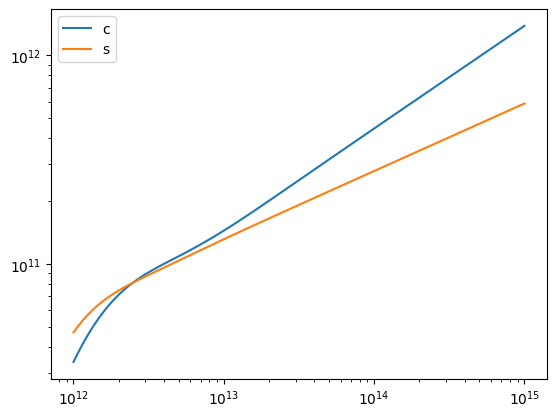

In [26]:
paramc, params = gals_init()

M = np.logspace(12, 15, 100)

plt.loglog(M, stellarmass_halomass(M, .6, paramc), label="c")
plt.loglog(M, stellarmass_halomass(M, .6, params), label="s")
plt.legend()